In [32]:
#input 4 
#input x,labled y,number of epochs,learning rate
#output bias,weight
#activation func sigmoid
#derivative derivative of sigmoid backpropogation
#Load input feature x,target output y
#Initialize weight and bias for input-hidden then hidden-output
#Calculate error MSE store that loss
#Update weight or BIas and store with min residue
#Plot loss vs epoch
#Plot activation func
#plot loss func
import numpy as np
import matplotlib.pyplot as plt
import random
import math

In [21]:
x=[0.2,0.4,0.6,0.8,1.0]
y=[1,2,3,4,5]                 
y_norm=[]
for i in y:
    y_norm.append(i/5)        #normalize for the sigmoid func so that range can lie b/w 0->1
print(y_norm)


[0.2, 0.4, 0.6, 0.8, 1.0]


In [22]:
w=random.uniform(-0.5,0.5)      #initializing random weight and bias 
b=random.uniform(-0.5,0.5)

In [23]:
def sigmoid(z):
    return 1 / (1 + math.exp(-z))

In [24]:
for x_i in x:
    z=w*x_i+b
    y_pred=sigmoid(z)
    
print(y_pred)
    

0.46044730404707623


In [25]:
error=[]
for i in y_norm:
    loss=i-y_pred
print("loss",loss)

loss 0.5395526959529238


In [26]:
errors = []  # list to store differences
for x_i,y_true in zip(x,y_norm):
    y_pred = sigmoid(w * x_i + b)  # or use x_i in a loop
    error = y_true - y_pred
    errors.append(error)

# Compute MSE
mse = sum(e**2 for e in errors) / len(errors)
print("MSE Loss:", mse)

MSE Loss: 0.09749795829769511


In [27]:
def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)


In [28]:
epochs = 1000
lr = 0.1


In [29]:
losses = []

best_loss = float('inf')
best_w, best_b = None, None

for epoch in range(epochs):
    errors = []
    
    for x_i, y_true in zip(x, y_norm):
        
        z = w * x_i + b
        y_pred = sigmoid(z)
        
        error = y_pred - y_true
        errors.append(error**2)
        
        dz = error * sigmoid_derivative(z)
        
        dw = dz * x_i
        db = dz
        
        w -= lr * dw
        b -= lr * db
    
    mse = sum(errors) / len(errors)
    losses.append(mse)
    
    # Store best weights
    if mse < best_loss:
        best_loss = mse
        best_w = w
        best_b = b

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {mse}")


Epoch 0, Loss: 0.09681274126103931
Epoch 100, Loss: 0.04388640646698156
Epoch 200, Loss: 0.032489304522951096
Epoch 300, Loss: 0.024566914294601665
Epoch 400, Loss: 0.018999901355755782
Epoch 500, Loss: 0.015015317774762452
Epoch 600, Loss: 0.012105129589551391
Epoch 700, Loss: 0.00993759045486554
Epoch 800, Loss: 0.00829383179150305
Epoch 900, Loss: 0.007026953294842464


In [30]:
print("Best Weight:", best_w)
print("Best Bias:", best_b)
print("Minimum Loss:", best_loss)


Best Weight: 3.4372258157957183
Best Bias: -1.6009349424710007
Minimum Loss: 0.006045201523937544


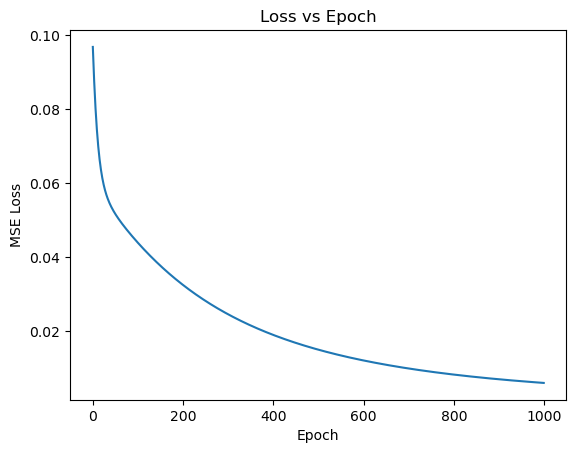

In [33]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Loss vs Epoch")
plt.show()


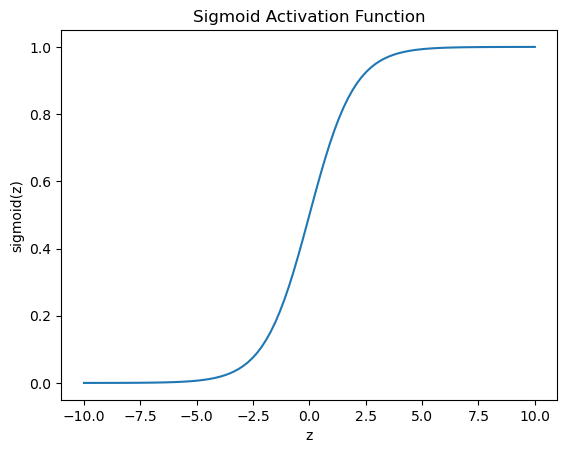

In [34]:
z_vals = np.linspace(-10, 10, 100)
sig_vals = [sigmoid(z) for z in z_vals]

plt.plot(z_vals, sig_vals)
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("Sigmoid Activation Function")
plt.show()
